In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
from  matplotlib.lines import Line2D

import numpy as np
import numpy.lib.recfunctions as rfn
from   numpy.polynomial.legendre import legval

import plotly.graph_objects as go
from ipywidgets import interact, IntSlider

from scipy.special import eval_legendre,legendre,factorial
from scipy.optimize import curve_fit, least_squares, differential_evolution

from Fonctions.Vopt import V_opt
from Fonctions.Metriques import rsq, rmse, mae
from Fonctions.Affichage import plot_interactif

# Import des données

In [2]:
# Tableau : Ar-HCN
Ar = np.genfromtxt("Data/Ar-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

# Conversion des µEh en mEh
energy_mEh = Ar['Energy'] * 1e-3
# Ajout de la colonne en Eh
Ar = rfn.append_fields(Ar, names='Energy_mEh', data=energy_mEh, usemask=False)

# Parametres donnés par Toczylowski
params_Ar = np.array([ 1.48547,   0.05926,  -0.07533,   0.12892,   0.04978,-0.00004, # b
                      -134348.77,-281277.47,-57041.638,-116961.41,                   # c
                       14.23209,  0.99248,  0.88287,    0.70551,   0.38213, 0.06818, # d
                       0.06053,  -0.12937,  0.07849,   -0.05992,   0.04541, 0.03519, # g0
                       0.00640,   0.04016, -0.02325,    0.02468,  -0.02338,-0.01536, # g1
                      -0.00277,  -0.00416,  0.00221,   -0.00239,   0.00392, 0.00207, # g2
                       0.00013,   0.00015, -0.00006,    0.00003,  -0.00021,-0.00009])# g3

# Implémentation des fonctions

In [3]:
def f6_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x / 720.0)))))
  return 1.0 - np.exp(-x) * y

def f7_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x * (1.0/720.0 + x / 5040.0))))))
  return 1.0 - np.exp(-x) * y

In [4]:
def V_opt(p, R, Theta):
  R = np.asarray(R, dtype=float)
  # On calcule ces valeurs car utiles plusieurs fois
  cosTh = np.cos(np.deg2rad(np.asarray(Theta, dtype=float)))

  # Paramètres
  b  = p[0:6]                            # b0, b1, b2, b3, b4, b5
  c  = p[6:10]                           # c0, c1, c2, c3
  d  = p[10:16]                          # d0, d1, d2, d3, d4, d5
  g0 = np.asarray(p[16:22], dtype=float) # g00, g01, g02, g03, g04, g05
  g1 = np.asarray(p[22:28], dtype=float) # g10, g11, g12, g13, g14, g15
  g2 = np.asarray(p[28:34], dtype=float) # g20, g21, g22, g23, g24, g25
  g3 = np.asarray(p[34:40], dtype=float) # g30, g31, g32, g33, g34, g35

  # X(theta) ------------------------------------ #
  # --------------------------------------------- #
  X_b = legval(cosTh, b)
  X_d = legval(cosTh, d)

  X_bR = X_b * R
  abs_BR = np.abs(X_bR)
  # --------------------------------------------- #

  # G(R,theta) ---------------------------------- #
  # --------------------------------------------- #
  i = np.arange(6)
  g = g0[i, None] + R * (g1[i, None] + R * (g2[i, None] + R * g3[i, None]))
  Pl = np.array([eval_legendre(l, cosTh) for l in range(6)])
  # G = np.sum(g * Pl, axis=0)
  # ------------------------------------------- #

  # Short-Range
  exp_val = np.clip(X_d-X_bR,-200,200) # Bloquage des valeurs trop grandes/petites
  V_sh = np.sum(g * Pl, axis=0) * np.exp(exp_val)

  # Asymptotic
  inv_R = 1.0/R
  inv_R6 = inv_R * inv_R * inv_R * inv_R * inv_R * inv_R
  inv_R7 = inv_R6 * inv_R

  V_as = (f6_opt(abs_BR) * legval(cosTh,[c[0],0,c[2]]) * inv_R6
        + f7_opt(abs_BR) * legval(cosTh,[0,c[1],0,c[3]]) * inv_R7)

  V_total = V_sh + V_as

  # Pour ne pas renvoyer NaN en cas d'erreur
  V_total = np.nan_to_num(V_total, nan=1e100, posinf=1e100, neginf=-1e100)
  # Bloquage des valeurs trop grandes
  V_total = np.clip(V_total, -1e100, 1e100)
  
  return V_total # Energie renvoyée en mEh

# Fonctions de métriques

In [5]:
def rsq(y, f):
  y = np.asarray(y)
  f = np.asarray(f)
  stot = np.sum((y-np.mean(y))**2)
  sres = np.sum((y-f)**2)
  return 1.0 - sres/stot


# y == valeurs tabulées

# f == f(x, y, popt)

In [6]:
def rmse(y, f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.sqrt(np.mean((y-f)**2))

In [7]:
def mae(y,f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.mean(np.abs(y-f))

# Fonction d'affichage

In [8]:
def plot_interactif(
    model,
    params,
    fixed_vals,
    x,
    data,
    fixed_col,
    x_col,
    y_col,
    title="Graphique interactif",
    fixed_first=True
):

    fig = go.Figure()

    for i, val in enumerate(fixed_vals):

        # ordre des variables
        if fixed_first:
            y_model = model(params, np.full_like(x, val), x)
        else:
            y_model = model(params, x, np.full_like(x, val))

        # données
        mask = np.isclose(data[fixed_col], val)

        x_data = data[x_col][mask]
        y_data = data[y_col][mask]

        order = np.argsort(x_data)

        visible = (i == 0)

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_model,
                mode='lines',
                name='Modèle',
                visible=visible
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x_data[order],
                y=y_data[order],
                mode='markers',
                name='Données',
                visible=visible
            )
        )

    steps = []

    for i, val in enumerate(fixed_vals):

        vis = [False] * (2 * len(fixed_vals))

        vis[2*i] = True
        vis[2*i+1] = True

        steps.append(
            dict(
                method="update",
                args=[
                    {"visible": vis},
                    {"title": f"{fixed_col} = {val}"}
                ],
                label=str(val)
            )
        )

    fig.update_layout(
        title=title,
        sliders=[dict(steps=steps)],
        template="plotly_white",
        width=600,
        height=400,
        uirevision=True
    )

    fig.show()

# Méthode 1 : curve_fit

In [9]:
def V_curvefit(vars, *p):
    R, Theta = vars
    return V_opt(p, R, Theta)

## Calculs

In [10]:
R = np.asarray(Ar["R"], dtype=float)
Theta = np.asarray(Ar["Theta"], dtype=float)
V_table = np.asarray(Ar["Energy_mEh"], dtype=float)
R.shape, Theta.shape, V_table.shape

((140,), (140,), (140,))

In [11]:
#params_init_cf = 10 * np.random.rand(40) - 5
#print(params_init_cf)
params_opt_cf, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_Ar, maxfev=1000000,
                                      method="lm")
params_opt_cf_sigma, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_Ar, maxfev=1000000,
                                      method="lm", sigma=V_table)

In [12]:
b  = params_opt_cf[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf[6:10]  # c0, c1, c2, c3
d  = params_opt_cf[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [1.4833413922718943, 0.11210825659602751, -0.03285233203367465, 0.09435351467692896, 0.033841179577699776, -0.004631208182246373]
[c0,c1,c2,c3]             = [-135782.7803631025, -325700.0072445246, -57995.995462126724, -125793.29821895949]
[d0,d1,d2,d3,d4,d5]       = [14.354611016839886, 1.211144747195666, 1.1271408471625632, 0.46632437593715687, 0.2640605229259021, 0.04369341692435883]
[g00,g01,g02,g03,g04,g05] = [0.045056225522880564, -0.15346319658571903, 0.029572096884871505, -0.029891893775907938, 0.013621363324805923, 0.009364347982767054]
[g10,g11,g12,g13,g14,g15] = [0.009030278981361885, 0.05135063460238532, -0.009027915297209324, 0.013755264144061717, -0.009102520151084146, -0.00515229677506785]
[g20,g21,g22,g23,g24,g25] = [-0.002962013418954556, -0.005518046318066193, 0.0011681140494451125, -0.0011981591807703686, 0.001863583770876061, 0.0007660945488849543]
[g30,g31,g32,g33,g34,g35] = [0.00013975608037574634, 0.00019602215936382518, -5.4625832589

In [13]:
print(params_opt_cf)
print(params_opt_cf_sigma)

[ 1.48334139e+00  1.12108257e-01 -3.28523320e-02  9.43535147e-02
  3.38411796e-02 -4.63120818e-03 -1.35782780e+05 -3.25700007e+05
 -5.79959955e+04 -1.25793298e+05  1.43546110e+01  1.21114475e+00
  1.12714085e+00  4.66324376e-01  2.64060523e-01  4.36934169e-02
  4.50562255e-02 -1.53463197e-01  2.95720969e-02 -2.98918938e-02
  1.36213633e-02  9.36434798e-03  9.03027898e-03  5.13506346e-02
 -9.02791530e-03  1.37552641e-02 -9.10252015e-03 -5.15229678e-03
 -2.96201342e-03 -5.51804632e-03  1.16811405e-03 -1.19815918e-03
  1.86358377e-03  7.66094549e-04  1.39756080e-04  1.96022159e-04
 -5.46258326e-05 -8.27875956e-06 -1.15484641e-04 -3.16266424e-05]
[ 1.23112305e+00  1.86792881e-02 -9.84045817e-02  1.70679991e-02
  3.66816485e-02  1.36012036e-02 -1.18420314e+05 -3.98664750e+05
 -2.63095786e+04 -1.72818783e+05  1.40443161e+01  9.62429476e-01
  3.11815360e-02  2.45635013e-01  3.23209633e-01  1.11743165e-01
  1.08799775e-01 -9.88334607e-02  1.47443418e-01 -2.93996268e-02
  2.18203059e-02 -1.3423

In [14]:
# Evaluation de la qualité du fit pour He-HCN
V_pred_cf = V_opt(params_opt_cf, R, Theta)
V_pred_cf_sigma = V_opt(params_opt_cf_sigma, R, Theta)
V_params_these = V_opt(params_Ar, R, Theta)

r2_cf = rsq(V_table, V_pred_cf)
r2_cf_sigma = rsq(V_table, V_pred_cf_sigma)
r2_params_these = rsq(V_table, V_params_these)

rmse_cf = rmse(V_table, V_pred_cf)
rmse_cf_sigma = rmse(V_table, V_pred_cf_sigma)
rmse_params_these = rmse(V_table, V_params_these)

mae_cf = mae(V_table, V_pred_cf)
mae_cf_sigma = mae(V_table, V_pred_cf_sigma)
mae_params_these = mae(V_table, V_params_these)

print(f"R² (sans sigma)         : {r2_cf}")
print(f"R² (avec sigma=y)       : {r2_cf_sigma}")
print(f"R² (paramètres these)   : {r2_params_these}")
print()
print(f"rmse (sans sigma)       : {rmse_cf}")
print(f"rmse (avec sigma=y)     : {rmse_cf_sigma}")
print(f"rmse (paramètres these) : {rmse_params_these}")
print()
print(f"mae (sans sigma)        : {mae_cf}")
print(f"mae (avec sigma=y)      : {mae_cf_sigma}")
print(f"mae (paramètres these)  : {mae_params_these}")

R² (sans sigma)         : 0.9999998091291987
R² (avec sigma=y)       : 0.9999910167165791
R² (paramètres these)   : 0.9973571231491378

rmse (sans sigma)       : 0.0011943245237204705
rmse (avec sigma=y)     : 0.008193513103426787
rmse (paramètres these) : 0.14053712510676145

mae (sans sigma)        : 0.0008700638846227479
mae (avec sigma=y)      : 0.00276581346507194
mae (paramètres these)  : 0.07967955352389043


# Affichage des résultats

## Plot à variable fixée

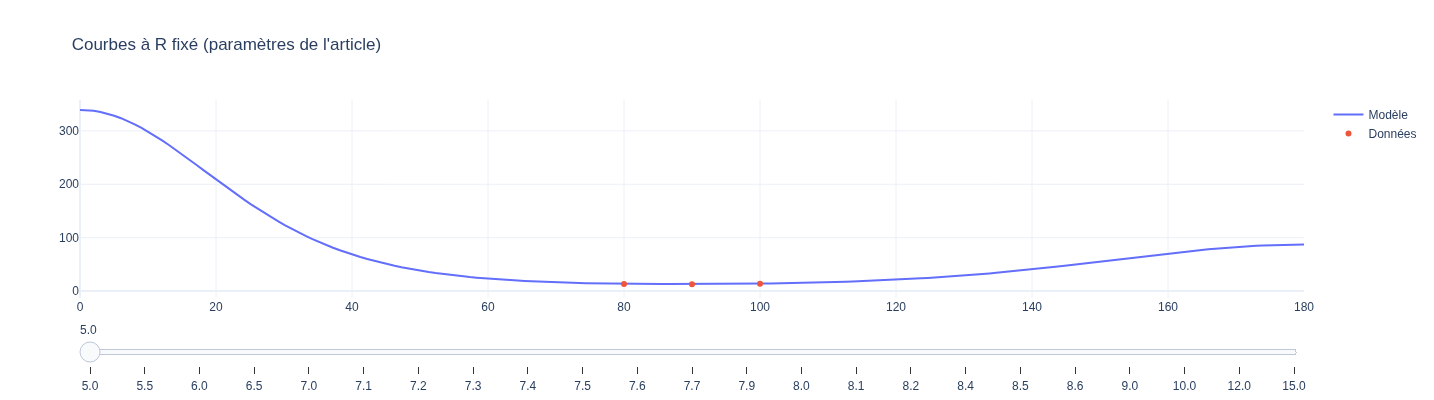

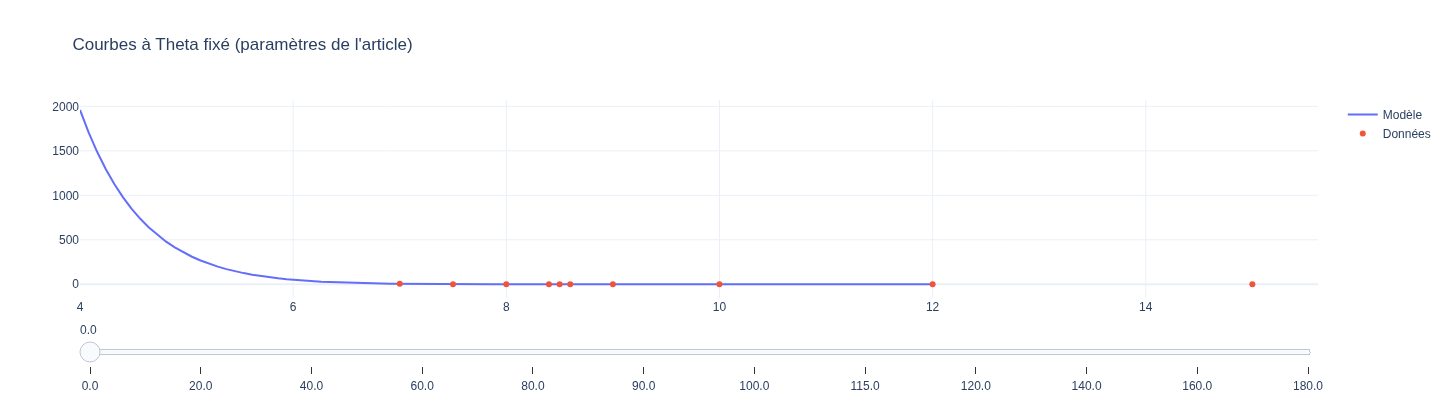

In [15]:
R_vals = np.array([5.0,5.5,6.0,6.5,7.0,7.1,7.2,7.3,7.4,7.5,7.6,7.7,
                   7.9,8.0,8.1,8.2,8.4,8.5,8.6,9.0,10.0,12.0,15.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_Ar, R_vals, x, Ar,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé (paramètres de l'article)")
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_Ar, Theta_vals, x_R, Ar,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé (paramètres de l'article)",fixed_first=False)

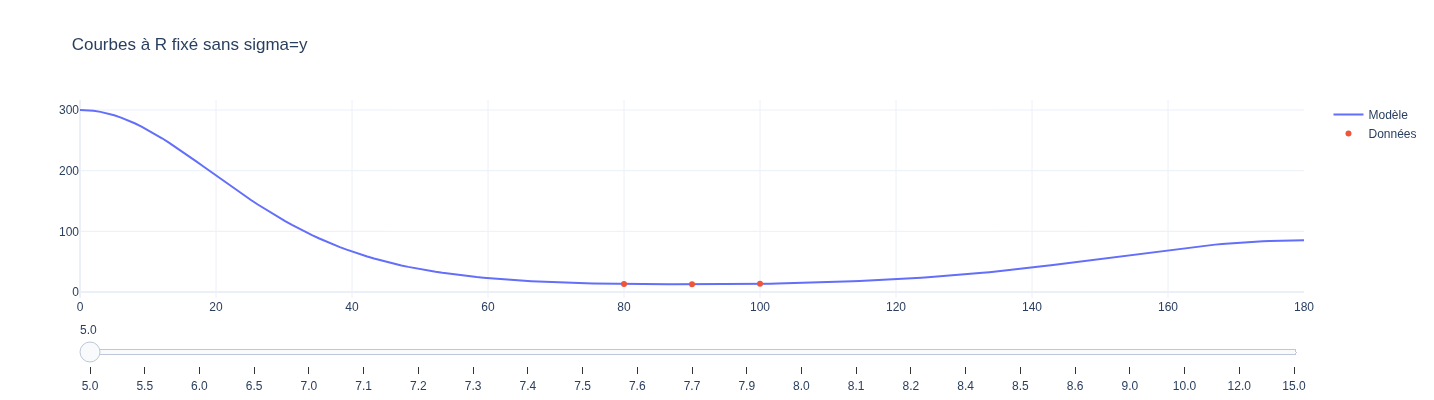

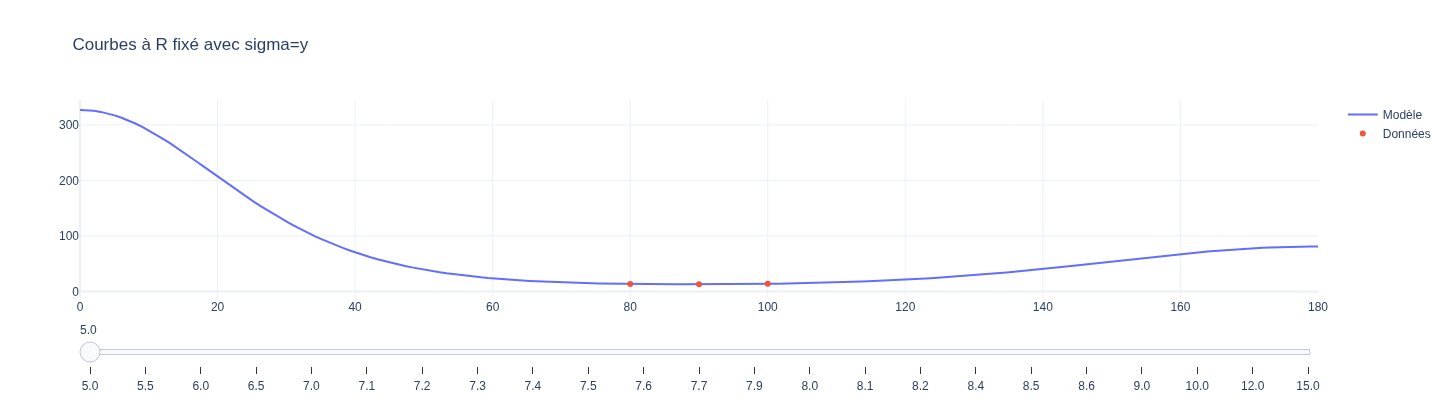

In [16]:
R_vals = np.array([5.0,5.5,6.0,6.5,7.0,7.1,7.2,7.3,7.4,7.5,7.6,7.7,
                   7.9,8.0,8.1,8.2,8.4,8.5,8.6,9.0,10.0,12.0,15.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_cf, R_vals, x, Ar,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans sigma=y")
plot_interactif(V_opt, params_opt_cf_sigma, R_vals, x, Ar,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec sigma=y")

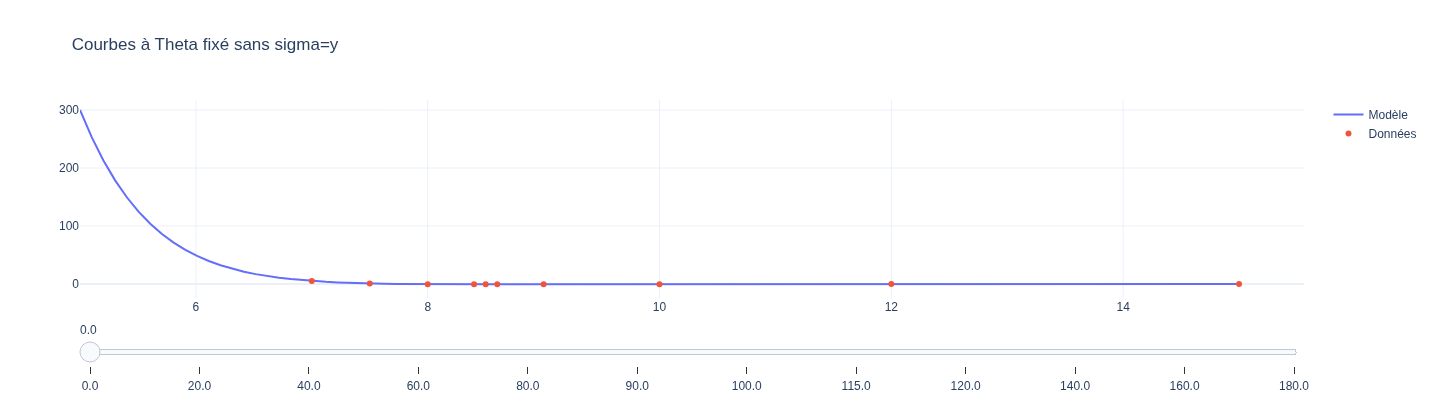

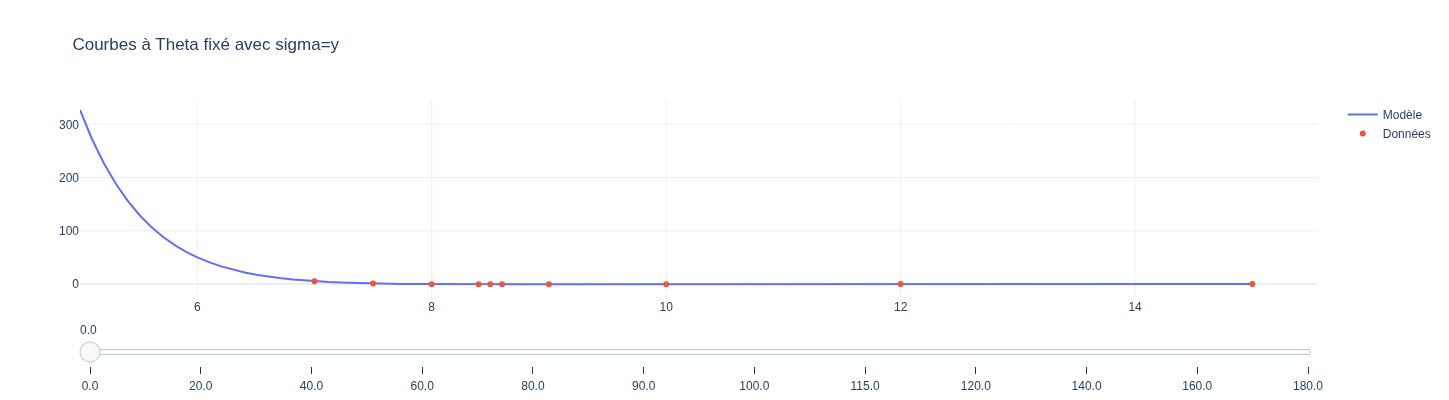

In [17]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(5, 15, 100)
plot_interactif(V_opt, params_opt_cf, Theta_vals, x_R, Ar,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé sans sigma=y",fixed_first=False)
plot_interactif(V_opt, params_opt_cf_sigma, Theta_vals, x_R, Ar,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

## Contour plot

In [18]:
def contour_plot(ax, params, title):
    # Axes
    theta_grid = np.linspace(0, 180, 250)
    r_grid = np.linspace(6, 10, 250)
    
    Theta_mesh, R_mesh = np.meshgrid(theta_grid, r_grid)
    
    # Calcul de Z
    Z = np.array([V_opt(params, np.full_like(theta_grid, r), theta_grid) for r in r_grid])
    
    # Niveaux à afficher
    levels_to_plot = np.array([
        -0.149, -0.189,
        -0.229, -0.269, -0.309, -0.349, -0.389, -0.429,
        -0.469, -0.489, -0.509, -0.549, -0.568, -0.588, 
        -0.629, -0.661
    ])
    # Niveaux pour lesquels on affiche une valeur
    levels_with_labels = np.array([
        -0.229, -0.309, -0.389, -0.469, -0.509,
        -0.549, -0.568, -0.629, -0.661
    ])
    
    # Niveaux intermédiaires
    levels_fine = []
    for i in range(len(levels_to_plot) - 1):
        a, b = levels_to_plot[i], levels_to_plot[i + 1]
        inter = np.linspace(a, b, 6)
        levels_fine.extend(inter[1:-1])
    
    levels_fine = np.sort(np.unique(levels_fine))
    
    # Contours principaux
    all_contours = []
    for level in levels_to_plot:
        cp = ax.contour(Theta_mesh, R_mesh, Z, levels=[level],
                        colors='black', linewidths=1.5, linestyles='--')
        all_contours.append(cp)

    # Contours gris
    ax.contour(Theta_mesh, R_mesh, Z, levels=levels_fine,
               colors='gray',linewidths=0.7)
    
    # Labels
    for cp in all_contours:
        level = cp.levels[0]
        if np.isclose(levels_with_labels, level).any():
            ax.clabel(cp, fmt='%.3f', fontsize=10, inline=True)

    r_values = [6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
    theta_dense = np.linspace(0, 180, 500) # Grille dense pour trouver le minimum avec précision

    # Affichage des Max et Min selon le R
    for r_val in r_values:
        energies = V_opt(params, np.full_like(theta_dense, r_val), theta_dense)

        # Minimum
        min_idx = np.argmin(energies)
        min_E = energies[min_idx]
        min_theta = theta_dense[min_idx]
        # Maximum
        max_idx = np.argmax(energies)
        max_E = energies[max_idx]
        max_theta = theta_dense[max_idx]
        
        # Affichage du point
        ax.plot(min_theta, r_val, marker='v', color='red', markersize=5)
        ax.plot(max_theta, r_val, marker='^', color='blue', markersize=5)
        
        # Affichage de la valeur
        ax.text(min_theta + 3, r_val, f"{min_E:.3f}", color='red', 
                fontsize=9, verticalalignment='center')
        ax.text(max_theta + 3, r_val, f"{max_E:.3f}", color='blue', 
                fontsize=9, verticalalignment='center')

    
    ax.set_title(f"Ar-HCN - Energie potentielle (mEh)\n{title}")
    ax.set_xlabel("Theta (°)")
    ax.set_ylabel("R")
    
    ax.set_yticks(np.arange(6, 10.5, 0.5))
    ax.set_xticks(np.arange(0, 181, 30))
    
    ax.grid(True, linestyle='--', alpha=0.3)
    
    legende_point1 = Line2D([0], [0], linestyle='None', marker='v', color='red', 
                           markersize=5, label="Energie min")
    legende_point2 = Line2D([0], [0], linestyle='None', marker='^', color='blue', 
                           markersize=5, label="Energie max")
    legende_point = [legende_point2, legende_point1]
    ax.legend(handles=legende_point,loc='upper right', fontsize=10, framealpha=0.9)

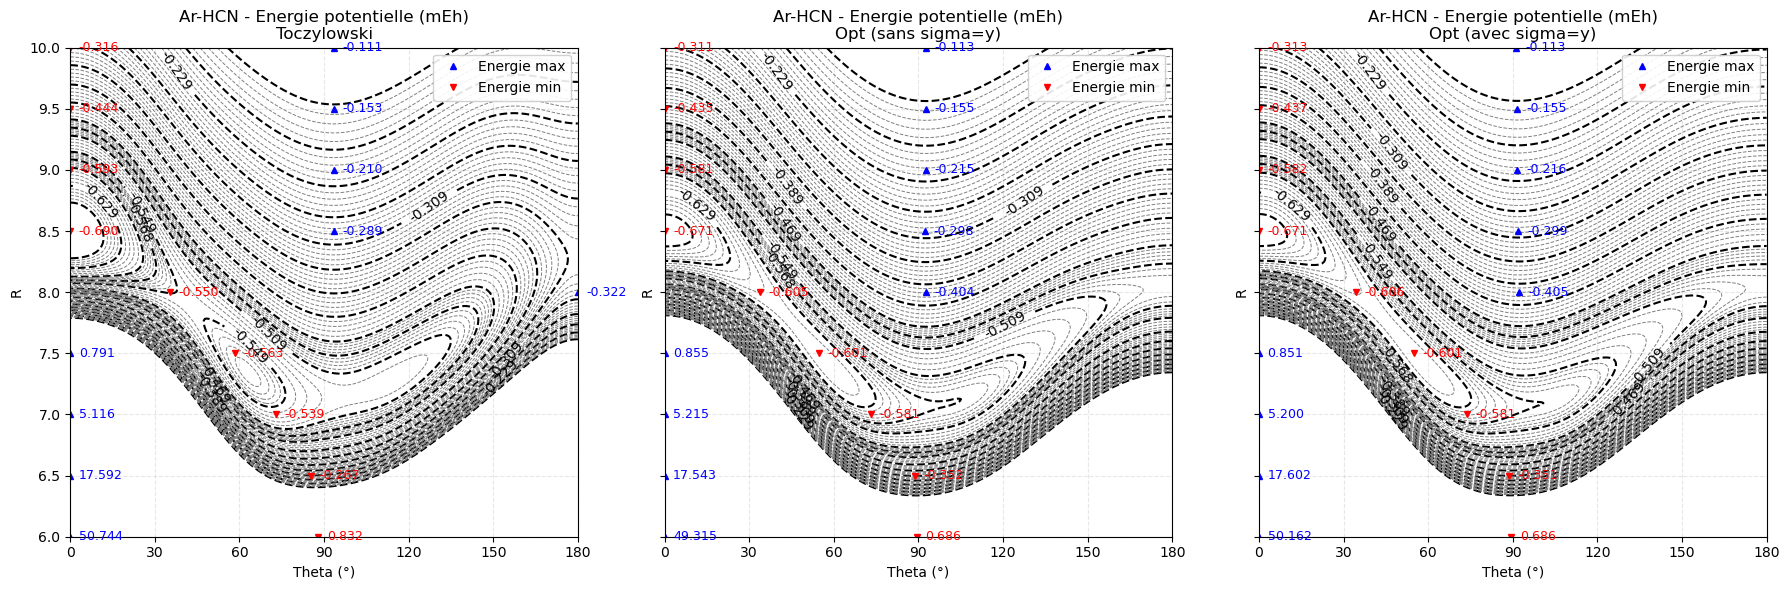

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

contour_plot(axes[0], params_Ar, "Toczylowski")
contour_plot(axes[1], params_opt_cf, "Opt (sans sigma=y)")
contour_plot(axes[2], params_opt_cf_sigma, "Opt (avec sigma=y)")

plt.tight_layout()

# Méthode 2 : least_squares

In [20]:
def residus_Ar(params):
    V_pred = V_opt(params, Ar["R"], Ar["Theta"])
    # .ravel() force le résultat en un tableau 1D pour least_squares
    return (V_pred - Ar["Energy_mEh"]).ravel()

In [21]:
result1 = least_squares(residus_Ar, params_Ar)
params_opt_ls = result1.x

result2 = least_squares(residus_Ar, params_Ar, x_scale = "jac")
params_opt_ls_jac = result2.x

In [22]:
result3 = least_squares(residus_Ar, params_Ar, 
                        x_scale = "jac", loss="soft_l1")
params_opt_ls_jac_soft = result3.x

In [23]:
result4 = least_squares(residus_Ar, params_Ar, 
                        x_scale = "jac", loss="huber")
params_opt_ls_jac_huber = result4.x

In [24]:
V_pred_ls = V_opt(params_opt_ls, R, Theta)
V_pred_ls_jac = V_opt(params_opt_ls_jac, R, Theta)
V_pred_ls_jac_soft = V_opt(params_opt_ls_jac_soft, R, Theta)
V_pred_ls_jac_huber = V_opt(params_opt_ls_jac_huber, R, Theta)

r2_ls = rsq(V_table, V_pred_ls)
r2_ls_jac = rsq(V_table, V_pred_ls_jac)
r2_ls_jac_soft = rsq(V_table, V_pred_ls_jac_soft)
r2_ls_jac_huber = rsq(V_table, V_pred_ls_jac_huber)

rmse_ls = rmse(V_table, V_pred_ls)
rmse_ls_jac = rmse(V_table, V_pred_ls_jac)
rmse_ls_jac_soft = rmse(V_table, V_pred_ls_jac_soft)
rmse_ls_jac_huber = rmse(V_table, V_pred_ls_jac_huber)

mae_ls = mae(V_table, V_pred_ls)
mae_ls_jac = mae(V_table, V_pred_ls_jac)
mae_ls_jac_soft = mae(V_table, V_pred_ls_jac_soft)
mae_ls_jac_huber = mae(V_table, V_pred_ls_jac_huber)

print(f"R²                                   : {r2_ls}")
print(f"R²   (x_scale='jac')                 : {r2_ls_jac}")
print(f"R²   (x_scale='jac', 'loss=soft_l1') : {r2_ls_jac_soft}")
print(f"R²   (x_scale='jac', 'loss=huber')   : {r2_ls_jac_huber}")
print()
print(f"rmse                                 : {rmse_ls}")
print(f"rmse (x_scale='jac')                 : {rmse_ls_jac}")
print(f"rmse (x_scale='jac', loss='soft_l1') : {rmse_ls_jac_soft}")
print(f"rmse (x_scale='jac', loss='huber')   : {rmse_ls_jac_huber}")
print()
print(f"mae                                  : {mae_ls}")
print(f"mae  (x_scale='jac')                 : {mae_ls_jac}")
print(f"mae  (x_scale='jac', loss='soft_l1') : {mae_ls_jac_soft}")
print(f"mae  (x_scale='jac', loss='huber')   : {mae_ls_jac_huber}")

R²                                   : 0.9999997616897787
R²   (x_scale='jac')                 : 0.9999998091292276
R²   (x_scale='jac', 'loss=soft_l1') : 0.9999998091292273
R²   (x_scale='jac', 'loss=huber')   : 0.9999998091292276

rmse                                 : 0.001334516465928862
rmse (x_scale='jac')                 : 0.0011943244333050733
rmse (x_scale='jac', loss='soft_l1') : 0.0011943244346639724
rmse (x_scale='jac', loss='huber')   : 0.0011943244333050733

mae                                  : 0.0009414680973702744
mae  (x_scale='jac')                 : 0.0008700564959377488
mae  (x_scale='jac', loss='soft_l1') : 0.0008700533824456864
mae  (x_scale='jac', loss='huber')   : 0.0008700564959377488


In [25]:
print(np.array2string(
    params_opt_ls_jac_soft,
    formatter={'float_kind': lambda x: f"{x:.12f}"}
))
print(np.array2string(
    params_opt_ls_jac_huber,
    formatter={'float_kind': lambda x: f"{x:.12f}"}
))

[1.483396287356 0.112023173233 -0.032848549728 0.094362235332
 0.033822791335 -0.004629111637 -135783.655639310164 -325693.583824209345
 -57995.625990073022 -125787.062666177604 14.371747537645 1.210380878281
 1.127298212263 0.466331719307 0.263969841561 0.043695307499
 0.044245495911 -0.150801942814 0.029002852151 -0.029377977374
 0.013408088273 0.009193332967 0.008900186758 0.050465237144
 -0.008850936998 0.013520413142 -0.008955454126 -0.005059642701
 -0.002914768694 -0.005423474643 0.001145488029 -0.001177322832
 0.001833002752 0.000752308093 0.000137491603 0.000192688274
 -0.000053585937 -0.000008191733 -0.000113574253 -0.000031048941]
[1.483464591718 0.111918433253 -0.032816834916 0.094382893258
 0.033807577274 -0.004628352214 -135785.120932984370 -325670.354554229649
 -57995.565593959138 -125773.353498349825 14.272315704367 1.209596573437
 1.127679794297 0.466424216163 0.263894913357 0.043691430837
 0.048816209295 -0.166492624815 0.031951885131 -0.032440088307
 0.014840408859 0.

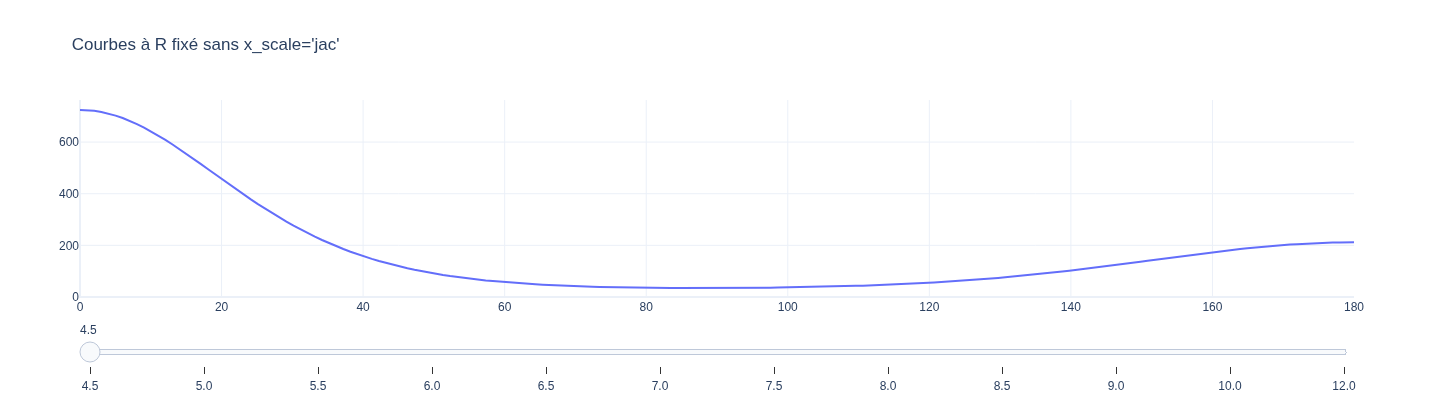

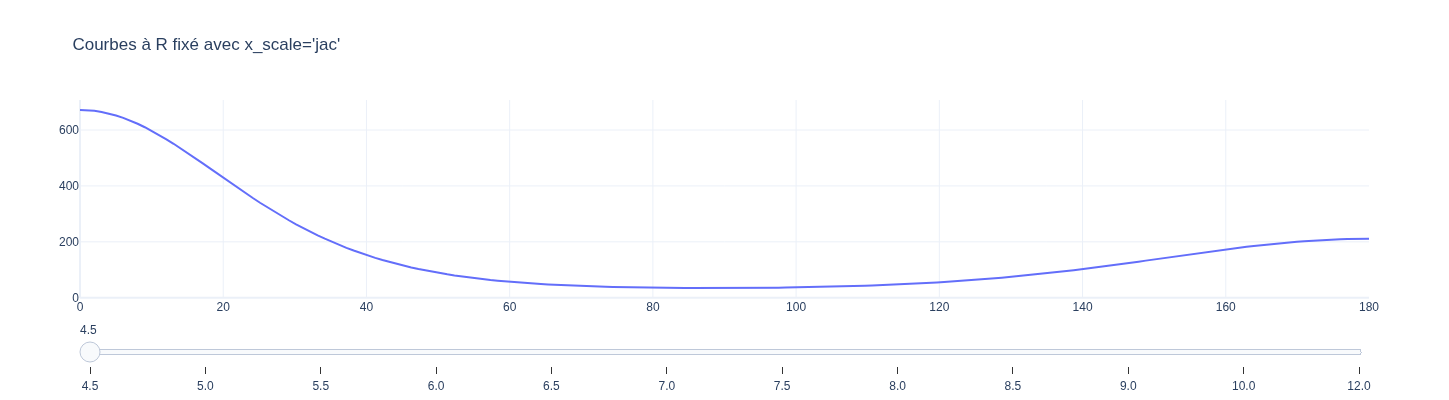

In [26]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_ls, R_vals, x, Ar,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, params_opt_ls_jac, R_vals, x, Ar,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")

In [27]:
# 1. Données d'entrée
#R_list = [5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 10.0, 12.0, 15.0]
R_list = [7.0, 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.9, 8.1, 8.2, 8.4, 8.6]
#Theta_list = [0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180]
Theta_list = [0, 45, 50, 55, 60, 90, 95, 100, 105, 180]

# 2. Calcul des énergies (en mEh)
res = np.array([
    V_opt(params_opt_ls_jac_huber, np.full_like(Theta_list, r, dtype=float), Theta_list)
    for r in R_list
])

# 3. Conversion de toute la matrice en µEh d'un seul coup
res_uEh = res * 1000

# 4. Configuration de l'affichage
largeur_r = 10  # Largeur pour la colonne de gauche 'R \ Theta'
largeur_th = 12  # Largeur pour chaque colonne de données
nb_colonnes = len(Theta_list)

# Ligne de séparation (|-------...-------|)
ligne_separation = "|" + "-" * (largeur_r + nb_colonnes * (largeur_th + 1)) + "|"

# --- Début de l'affichage ---

print(ligne_separation)
# Entête
entete_cols = "".join(f" {th:>{largeur_th}}" for th in Theta_list)
print(f"|{'R \\ Theta':<{largeur_r}}{entete_cols} |")
print(ligne_separation)

# Remplissage des lignes de données
for i, r in enumerate(R_list):
    # Colonne R
    ligne_str = f"|  {r:<{largeur_r-2}.1f}|"

    # Parcours des valeurs précalculées pour cette ligne (ce R)
    for val_uEh in res_uEh[i]:
        # Affichage de la valeur à 4 décimales, calée à droite
        ligne_str += f" {val_uEh:>{largeur_th}.4f}"

    ligne_str += " |"
    print(ligne_str)

print(ligne_separation)

|--------------------------------------------------------------------------------------------------------------------------------------------|
|R \ Theta             0           45           50           55           60           90           95          100          105          180 |
|--------------------------------------------------------------------------------------------------------------------------------------------|
|  7.0     |    5215.1224     -88.9292    -309.8659    -447.3273    -525.3614    -568.4209    -566.3517    -564.6159    -561.1836     602.3571 |
|  7.1     |    3926.1370    -249.4776    -414.5643    -513.4033    -565.6570    -569.8412    -568.2840    -568.1958    -567.8074     314.8804 |
|  7.2     |    2885.2601    -370.1781    -490.0779    -557.8657    -589.5793    -563.7663    -562.6049    -563.7683    -565.7133      89.7115 |
|  7.3     |    2049.5392    -458.4675    -542.0334    -585.0439    -600.5472    -552.0101    -551.1529    -553.2493    -556.9519     -